# Moving average for all CSV files

선택한 폴더 안의 모든 CSV 파일을 읽어서 이동평균을 적용하고, 원본/필터 결과를 plot으로 확인한 뒤, 새 폴더에 저장하는 노트북입니다.

In [5]:
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== settings =====
folder_path = r"C:\Users\user\Downloads\MJ LED\새 폴더"

window_size = 10          # 이동평균 window 크기
min_periods = 1           # 초반 구간도 계산하려면 1 유지
center = False            # True면 centered moving average
save_header = True        # 저장 시 column 이름 포함 여부
max_plots = None          # None이면 모든 파일 plot, 예: 5

Input folder : C:\Users\user\Downloads\MJ LED\새 폴더
Output folder: C:\Users\user\Downloads\MJ LED\새 폴더_moving_average_w10
Window size  : 10
Found 1 CSV files
[1/1] Processing: Time-Norm.csv


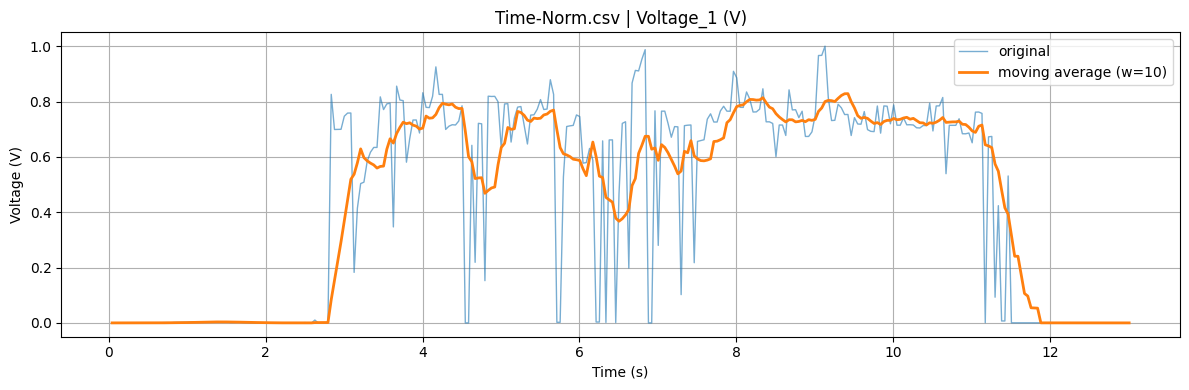


Saved 1 filtered CSV files to:
C:\Users\user\Downloads\MJ LED\새 폴더_moving_average_w10


In [6]:
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

folder_path = os.path.normpath(folder_path)
input_folder = Path(folder_path)
output_folder = input_folder.parent / f"{input_folder.name}_moving_average_w{window_size}"
output_folder.mkdir(exist_ok=True)

print(f"Input folder : {input_folder}")
print(f"Output folder: {output_folder}")
print(f"Window size  : {window_size}")

csv_files = sorted(glob.glob(os.path.join(glob.escape(folder_path), "*.csv")))

if not csv_files:
    raise FileNotFoundError(f"CSV 파일이 없습니다: {folder_path}")

print(f"Found {len(csv_files)} CSV files")

def read_csv_flexible(file_path: str) -> pd.DataFrame:
    """첫 번째 숫자형 컬럼은 시간축, 나머지는 전압 데이터로 읽습니다."""
    read_options = [
        {"header": 0, "encoding": "utf-8-sig"},
        {"header": None, "encoding": "utf-8-sig"},
        {"header": 0, "encoding": "cp949"},
        {"header": None, "encoding": "cp949"},
    ]

    last_error = None
    for options in read_options:
        try:
            df = pd.read_csv(file_path, **options)
            break
        except Exception as exc:
            last_error = exc
    else:
        raise last_error

    df = df.dropna(axis=1, how="all").dropna(axis=0, how="all")

    numeric_df = df.apply(pd.to_numeric, errors="coerce")
    numeric_df = numeric_df.dropna(axis=1, how="all").dropna(axis=0, how="all")

    if numeric_df.empty:
        raise ValueError("숫자형 데이터가 없습니다.")

    numeric_df = numeric_df.reset_index(drop=True)

    if len(numeric_df.columns) < 2:
        raise ValueError("최소 2개 컬럼이 필요합니다. (Time, Voltage)")

    numeric_df.columns = ["Time (s)"] + [f"Voltage_{i} (V)" for i in range(1, len(numeric_df.columns))]

    return numeric_df


def apply_moving_average(df: pd.DataFrame, window: int, min_periods: int = 1, center: bool = False) -> pd.DataFrame:
    filtered = df.copy()
    value_columns = [col for col in df.columns if col != "Time (s)"]
    filtered[value_columns] = filtered[value_columns].rolling(
        window=window,
        min_periods=min_periods,
        center=center,
    ).mean()
    return filtered


def plot_original_vs_filtered(original: pd.DataFrame, filtered: pd.DataFrame, title: str) -> None:
    time_col = "Time (s)"
    value_columns = [col for col in original.columns if col != time_col]
    n_cols = len(value_columns)
    fig, axes = plt.subplots(n_cols, 1, figsize=(12, max(4, 3 * n_cols)), squeeze=False)

    for i, col in enumerate(value_columns):
        ax = axes[i, 0]
        ax.plot(original[time_col], original[col], label="original", alpha=0.6, linewidth=1)
        ax.plot(filtered[time_col], filtered[col], label=f"moving average (w={window_size})", linewidth=2)
        ax.set_title(f"{title} | {col}")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Voltage (V)")
        ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

saved_files = []

for file_idx, file_path in enumerate(csv_files, start=1):
    file_name = os.path.basename(file_path)
    print(f"[{file_idx}/{len(csv_files)}] Processing: {file_name}")

    try:
        original_df = read_csv_flexible(file_path)
        filtered_df = apply_moving_average(
            original_df,
            window=window_size,
            min_periods=min_periods,
            center=center,
        )

        save_path = output_folder / file_name
        filtered_df.to_csv(save_path, index=False, header=save_header)
        saved_files.append(save_path)

        should_plot = max_plots is None or file_idx <= max_plots
        if should_plot:
            plot_original_vs_filtered(original_df, filtered_df, file_name)

    except Exception as exc:
        print(f"  -> skipped: {file_name} | reason: {exc}")

print()
print(f"Saved {len(saved_files)} filtered CSV files to:")
print(output_folder)